# EDA

データ確認・欠損値・外れ値の把握

In [1]:
import pandas as pd

train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")
train.shape, test.shape

((1460, 81), (1459, 80))

## 1. データ概要(型・欠損値・基本統計量)

In [2]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [3]:
# 欠損値の割合(train/test)
missing_train = train.isnull().mean().rename("train")
missing_test = test.isnull().mean().rename("test")
missing = pd.concat([missing_train, missing_test], axis=1).fillna(0)
missing = missing[(missing["train"] > 0) | (missing["test"] > 0)].sort_values("train", ascending=False)
missing

,train,test
PoolQC,0.995205,0.997944
MiscFeature,0.963014,0.965045
Alley,0.937671,0.926662
Fence,0.807534,0.801234
MasVnrType,0.597260,0.612748
FireplaceQu,0.472603,0.500343
LotFrontage,0.177397,0.155586
GarageYrBlt,0.055479,0.053461
GarageFinish,0.055479,0.053461
GarageCond,0.055479,0.053461


## 2. ターゲット(SalePrice)の分布

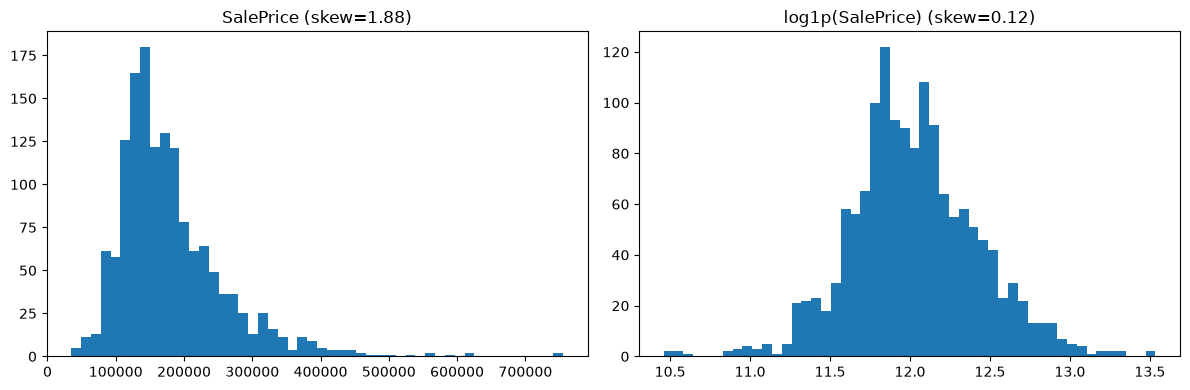

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import skew

fig_dir = Path("../reports/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train["SalePrice"], bins=50)
axes[0].set_title(f"SalePrice (skew={skew(train['SalePrice']):.2f})")
axes[1].hist(np.log1p(train["SalePrice"]), bins=50)
axes[1].set_title(f"log1p(SalePrice) (skew={skew(np.log1p(train['SalePrice'])):.2f})")
plt.tight_layout()
plt.savefig(fig_dir / "target_distribution.png", dpi=100)
plt.show()

train["SalePrice"].describe()

## 3. 数値特徴量とSalePriceの相関

In [5]:
num_cols = train.select_dtypes(include=[np.number]).columns.drop(["Id", "SalePrice"])
corr = train[num_cols].corrwith(train["SalePrice"]).sort_values(ascending=False)
corr.head(15)

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
dtype: float64

## 4. 既知の外れ値パターン(GrLivAreaが大きいのに価格が低い)

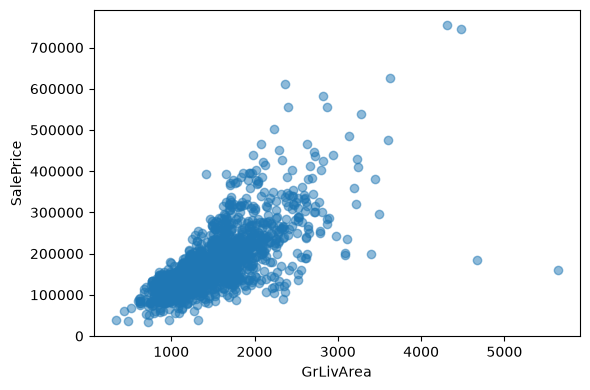

,Id,GrLivArea,SalePrice
523,524,4676,184750
1298,1299,5642,160000


In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(train["GrLivArea"], train["SalePrice"], alpha=0.5)
ax.set_xlabel("GrLivArea")
ax.set_ylabel("SalePrice")
plt.tight_layout()
plt.savefig(fig_dir / "grlivarea_vs_saleprice.png", dpi=100)
plt.show()

outliers = train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)]
outliers[["Id", "GrLivArea", "SalePrice"]]

## 5. カテゴリ変数のカーディナリティ

In [7]:
cat_cols = train.select_dtypes(include=["object"]).columns
cardinality = train[cat_cols].nunique().sort_values(ascending=False)
cardinality

C:\Users\a0419\AppData\Local\Temp\ipykernel_21076\1266925096.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include=["object"]).columns


Neighborhood     25
Exterior2nd      16
Exterior1st      15
Condition1        9
SaleType          9
HouseStyle        8
RoofMatl          8
Condition2        8
Functional        7
BsmtFinType2      6
RoofStyle         6
BsmtFinType1      6
SaleCondition     6
Heating           6
Foundation        6
GarageType        6
ExterCond         5
LotConfig         5
MSZoning          5
GarageCond        5
GarageQual        5
HeatingQC         5
Electrical        5
BldgType          5
FireplaceQu       5
LandContour       4
LotShape          4
KitchenQual       4
MiscFeature       4
Fence             4
BsmtCond          4
ExterQual         4
BsmtExposure      4
BsmtQual          4
LandSlope         3
PoolQC            3
GarageFinish      3
PavedDrive        3
MasVnrType        3
Utilities         2
Alley             2
Street            2
CentralAir        2
dtype: int64